# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [44]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [45]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [46]:
plans.head(5) # mostrar las primeras 5 filas de plans

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [47]:
users.head(5)# mostrar las primeras 5 filas de users

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [48]:
usage.head(5)# mostrar las primeras 5 filas de usage

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [49]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [50]:
plans.info() # inspección de plans con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [51]:
users.info()# inspección de users con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [52]:
usage.info()# inspección de usage con .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [53]:
# cantidad de nulos para users

city_missing = users["city"].isna().sum()
churn_missing = users["churn_date"].isna().sum()

print("Cantidad de valores nulos de la columna 'city' del DF USERS:", city_missing)
print("Cantidad de valores nulos de la columna 'churn_date' del DF USERS:", churn_missing)


city_missing_pct = users["city"].isna().mean()
churn_missing_pct = users["churn_date"].isna().mean()

print()
print("Proporción de valores nulos de la columna 'city' del DF USERS", city_missing_pct)
print("Proporción de valores nulos de la columna 'churn_date' del DF USERS", churn_missing_pct)

Cantidad de valores nulos de la columna 'city' del DF USERS: 469
Cantidad de valores nulos de la columna 'churn_date' del DF USERS: 3534

Proporción de valores nulos de la columna 'city' del DF USERS 0.11725
Proporción de valores nulos de la columna 'churn_date' del DF USERS 0.8835


In [54]:
# cantidad de nulos para usage

date_missing = usage['date'].isna().sum()
duration_missing = usage['duration'].isna().sum()
length_missing = usage['length'].isna().sum()

print("Cantidad de valores nulos de la columna 'date' del DF USAGE:",date_missing)
print("Cantidad de valores nulos de la columna 'duration' del DF USAGE:",duration_missing)
print("Cantidad de valores nulos de la columna 'length' del DF USAGE:",length_missing)
print()
date_missing_pct = usage['date'].isna().mean()
duration_missing_pct = usage['duration'].isna().mean()
length_missing_pct = usage['length'].isna().mean()

print("Proporcion de valores nulos de la columna 'date' del DF USAGE:",date_missing_pct)
print("Proporcion de valores nulos de la columna 'duration' del DF USAGE:",duration_missing_pct)
print("Proporcion de valores nulos de la columna 'length' del DF USAGE:",length_missing_pct)

Cantidad de valores nulos de la columna 'date' del DF USAGE: 50
Cantidad de valores nulos de la columna 'duration' del DF USAGE: 22076
Cantidad de valores nulos de la columna 'length' del DF USAGE: 17896

Proporcion de valores nulos de la columna 'date' del DF USAGE: 0.00125
Proporcion de valores nulos de la columna 'duration' del DF USAGE: 0.5519
Proporcion de valores nulos de la columna 'length' del DF USAGE: 0.4474


In [55]:
print(usage.groupby("type")[["duration","length"]].count())

      duration  length
type                  
call     17908      12
text        16   22092


In [56]:
print(usage[usage['duration'].isna() & usage['length'].isna()])

Empty DataFrame
Columns: [id, user_id, type, date, duration, length]
Index: []


In [57]:
print((usage['duration'].isna() & usage['length'].isna()).sum())

0


In [58]:
print((usage['duration'].notna() & usage['length'].notna()).sum())

28


In [59]:
print(usage[usage['duration'].notna() & usage['length'].notna()])

          id  user_id  type                           date  duration  length
1414    1415    10399  text  2024-01-07 09:33:51.260781519    120.00    65.0
1824    1825    12936  text  2024-01-09 06:05:28.868221705    120.00    40.0
1932    1933    10189  text  2024-01-09 17:49:13.603840096    120.00    69.0
2070    2071    13139  call  2024-01-10 08:48:27.432685817      1.68  1490.0
2972    2973    10085  text  2024-01-14 10:46:02.169054226    120.00    68.0
5272    5273    11750  call  2024-01-24 20:33:12.649816245      3.78  1490.0
10614  10615    13855  call  2024-02-18 00:42:33.183829595      0.53  1490.0
11456  11457    13325  text  2024-02-21 20:09:09.733743343    120.00    23.0
12692  12693    12263  call  2024-02-27 10:23:08.374709367      1.80  1490.0
16702  16703    10484  text  2024-03-16 13:52:57.169429235    120.00    48.0
16910  16911    12099  call  2024-03-17 12:28:18.882472061      3.29  1490.0
20727  20728    10599  call  2024-04-03 19:00:30.510762768      0.40  1490.0

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Como se observó en la exploracion, el dataset "plans" no contiene valores nulos en sus columnas, por lo que no se le realizará ninguna modificacion.

El dataset "users" tiene en su columna 'city' un total de 469 valores nulos lo que representa el 11.73% por lo que se dejarán como nulos, ya que al revisar la informacion completa no tenemos otro indicador para asignar la ciudad correcta, y si ponemos cualquier ciudad podriamos estar modificando el comportamiento del mercado en cada region. En lo que respecta a la columna 'churn_date' observamos que tiene un cantidad total de 3534 valores nulos o vacios, lo que representa el 88.35% de todos los registros, es por esto que esta columna se ignorará para analisis, se utilizará solo para referencia en caso necesario.

El dataset "usage" tiene en su columna 'date' un total de 50 valores nulos, por lo que se buscará imputacion simple por eliminacion ya que no representan una afectacion al analisis. En el caso de las columnas 'duration' y 'length', ambas tienen una proporcion cercana al 50%, ademas son las columnas sobre las que se puede basar el analisis del mercado,haciendo una observacion detallada observamos que los datos faltantes en cada columna corresponden al tipo de servicio que se registró, es decir, los valores nulos en la columna duration, corresponden al servicio "text" de la columna 'type' y los valores ausentes en la columna 'length' corresponden al servicio "call" de la columna 'type', por lo que no se pueden modificar. Ademas observamos que los valores que acompañan al tipo de servicio, son un tipo de sentinnel, por lo repeticion de valores (120,1490 respectivamente)

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [60]:
print(users[['age','user_id']].describe()) # explorar columnas numéricas de users

               age       user_id
count  4000.000000   4000.000000
mean     33.739750  11999.500000
std     123.232257   1154.844867
min    -999.000000  10000.000000
25%      32.000000  10999.750000
50%      47.000000  11999.500000
75%      63.000000  12999.250000
max      79.000000  13999.000000


- La columna `user_id` es numerica, pero no muestra ningun desempeño estadistico ya que las cantidades representan etiquetas de usuarios, que a su vez no estan debidamente identificados, unicamente se asigna un numero consecutivo al usuario que mas bien corresponderia a un numero de operacion.
- La columna `age` nos muestra la dispersion de las edades de los clientes, pero nos muestra ademas el uso de sentinels (valor -999) para identificar usuarios u operaciones que se tienen que analizar mas a detalle, ya que es imposible que una persona tenga 999 años y menos que sea una cantidad negativa

In [61]:
print(usage[['id','user_id','duration','length']].describe()) # explorar columnas numéricas de usage

                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000


In [62]:
print(usage['user_id'].value_counts())

13819    27
13100    22
13772    22
13255    22
13475    21
         ..
12448     2
11891     2
10226     2
13923     2
12058     1
Name: user_id, Length: 3999, dtype: int64


- Las columnas `id` y `user_id` son diferentes, ya que 'id' esta identificando la operacion y por ello podremos ver la cantidad de operaciones que se realizan, y 'user_id' esta identificando a la persona que la realiza por lo que podemos ver cuántas veces un mismo usuario utiliza un servicio de la empresa
- Las columnas ...

In [63]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
print(users[columnas_user].describe())


          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595


- La columna `city` nos dice que tenemos un total de 3531 de 4000 datos validos, es decir que de los 4000 usuarios registrados faltan 469, con 7 ciudades diferentes y que la ciudad con una mayor cantidad de usuarios es Bogotá.
- La columna `plan` nos dice que tenemos todos los usuarios asignados a uno de los 2 planes que ofrece la empresa, siendo el mas contratado el plan Básico con un total de 2595 usuarios del total de las 4000 registrados. 

In [64]:
# explorar columna categórica de usage
usage['type'].describe() # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

In [65]:
(usage['duration'].value_counts()[120] / 40000) * 100

0.075

In [66]:
(usage['length'].value_counts()[1490] / 40000) * 100

0.075

- La columna `type` nos dice que de las 40000 operaciones registrados, tenemos 2 servicios diferentes, siendo el mas utilizado el de texto "text" con un total 22092 servicios registrados.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- en las columnas 'length'(valor: 1490) y 'duration'(valor: 120) es donde se encontraron sentinnels 
- ¿Qué acción tomarías?
- dado que la cantidad de sentinnels encontrados es irrelevante (0.075 % de los registros) en ambas columnas, simplemente los eliminaria para no afectar el analisis

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [67]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors= "coerce") # completa el código

In [68]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors= "coerce") # completa el código

In [69]:
users.info() # Revisar los años presentes en `reg_date` de users


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     4000 non-null   int64         
 1   first_name  4000 non-null   object        
 2   last_name   4000 non-null   object        
 3   age         4000 non-null   int64         
 4   city        3531 non-null   object        
 5   reg_date    4000 non-null   datetime64[ns]
 6   plan        4000 non-null   object        
 7   churn_date  466 non-null    object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 250.1+ KB


In [70]:
users['reg_date'].dt.year.value_counts().sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observa que tenemos registros con fechas del 2026(40), que representan errores de captura ya que segun la informacion proporcionada los registros corresponden unicamente hasta el año 2024

In [71]:
usage.info() # Revisar los años presentes en `date` de usage


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   id        40000 non-null  int64         
 1   user_id   40000 non-null  int64         
 2   type      40000 non-null  object        
 3   date      39950 non-null  datetime64[ns]
 4   duration  17924 non-null  float64       
 5   length    22104 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 1.8+ MB


In [72]:
usage['date'].dt.year.value_counts().sort_index()

2024.0    39950
Name: date, dtype: int64

En `date`, observamos que son datos unicamente del año 2024 y aparte tenemos un error de sistema en 50 registros ya que presentan datos invalidos o nulos, pero al ser una cantidad irrelevante vamos a eliminar esos registros. 
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- si aparecen años "imposibles" con respecto a esta empresa, en la dataframe "users", ya que nos muestra usuarios registrados "en el futuro", por lo que para el analisis es algo imposible, ya que estamos situados en el año 2024. 
- ¿Qué harías con ellas?
- analizando la cantidad de registros con este error, 40 registros que representan solo el 1% de toda la columna,  lo mejor es eliminarlos para que no afecten un posible analisis con outliers en la frecuencia de usuarios registrados anualmente.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [73]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace((-999), np.nan)
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [74]:
# Reemplazar ? por NA en city
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [75]:
users['city'] = users['city'].replace(('?'), np.nan)

users['city'].value_counts()
# Verificar cambios


Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [76]:
users.loc[users['reg_date'].dt.year ==2026,'reg_date'] = pd.NaT # Marcar fechas futuras como NA para reg_date


# Verificar cambios
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [77]:
# Verificación MAR en usage (Missing At Random) para duration
print("valores nulos en 'duration' segun 'type':")
print(usage.groupby("type")['duration'].apply(lambda x: x.isna().mean() * 100).round(2))

print(usage.groupby("type")["duration"].agg(total_registros = "size", valores_nulos = lambda x: x.isna().sum()))

valores nulos en 'duration' segun 'type':
type
call     0.00
text    99.93
Name: duration, dtype: float64
      total_registros  valores_nulos
type                                
call            17908            0.0
text            22092        22076.0


In [78]:
# Verificación MAR en usage (Missing At Random) para length
print("Valores nulos de length según type:")
print(usage.groupby("type")["length"].apply(lambda x: x.isna().mean() * 100).round(2))

# Tabla de conteos
print(usage.groupby("type")["length"].agg(total_registros="size",valores_nulos=lambda x: x.isna().sum(),
        valores_presentes=lambda x: x.notna().sum()))

Valores nulos de length según type:
type
call    99.93
text     0.00
Name: length, dtype: float64
      total_registros  valores_nulos  valores_presentes
type                                                   
call            17908        17896.0               12.0
text            22092            0.0            22092.0


Los valores ausentes de duration y length dependen del tipo de servicio registrado en la columna type. Los registros de tipo call contienen información en duration, pero no requieren un valor en length. Por otro lado, los registros de tipo text contienen información en length, pero no requieren duración.

Por lo tanto, los valores ausentes no parecen ser errores de captura, sino valores estructurales asociados al tipo de servicio. Pueden considerarse MAR porque su ausencia puede explicarse mediante la variable observada type. Se decidió conservarlos como valores nulos, ya que reemplazarlos con cero, la media o la mediana introduciría información artificial y podría distorsionar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [79]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({"is_text": "sum","is_call": "sum","duration": "sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [80]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text": "cant_mensajes","is_call": "cant_llamadas","duration": "cant_minutos_llamada"})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [81]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on="user_id",how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


In [82]:
columnas_uso = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]

user_profile[columnas_uso] = user_profile[columnas_uso].fillna(0)

In [83]:
user_profile["cant_mensajes"] = user_profile["cant_mensajes"].astype(int)
user_profile["cant_llamadas"] = user_profile["cant_llamadas"].astype(int)

### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [84]:
# Resumen estadístico de las columnas numéricas
columnas_numericas = ["age","cant_mensajes","cant_llamadas","cant_minutos_llamada"]

user_profile[columnas_numericas].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,48.122250,5.523000,4.477000,23.311225
std,17.690408,2.359738,2.145139,18.169564
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.107500
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.412500
max,79.000000,17.000000,15.000000,155.690000


In [85]:
user_profile[columnas_numericas].agg(["count","mean","median","std","min","max"]).round(2)

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.00,4000.00,4000.00,4000.00
mean,48.12,5.52,4.48,23.31
median,47.00,5.00,4.00,19.78
std,17.69,2.36,2.15,18.17
min,18.00,0.00,0.00,0.00
max,79.00,17.00,15.00,155.69


In [86]:
# Distribución porcentual del tipo de plan
distribucion_plan = (user_profile["plan"].value_counts(normalize=True).mul(100).round(2))

distribucion_plan

distribucion_plan.astype(str) + "%"

Basico     64.88%
Premium    35.12%
Name: plan, dtype: object

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

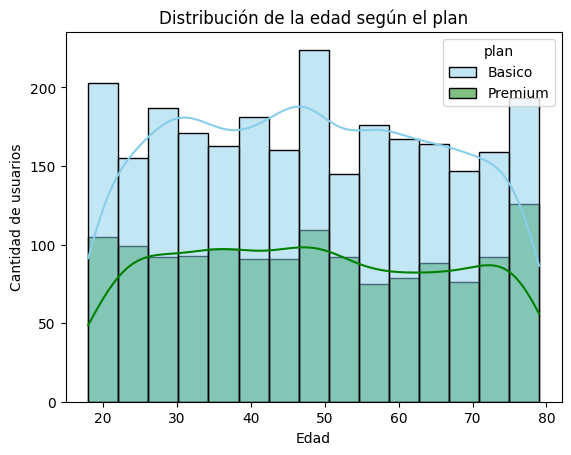

In [88]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x="age",hue="plan",palette=["skyblue", "green"],bins=15,kde=True,alpha=0.5)
plt.title("Distribución de la edad según el plan")
plt.xlabel("Edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La distribución muestra cómo se concentran las edades de los clientes de cada plan. Se debe observar si el plan Premium tiene una mayor presencia en ciertos rangos de edad o si ambos planes presentan una distribución similar. La forma de la distribución se determinará comparando la posición de la mayor concentración de usuarios con la extensión de las colas.

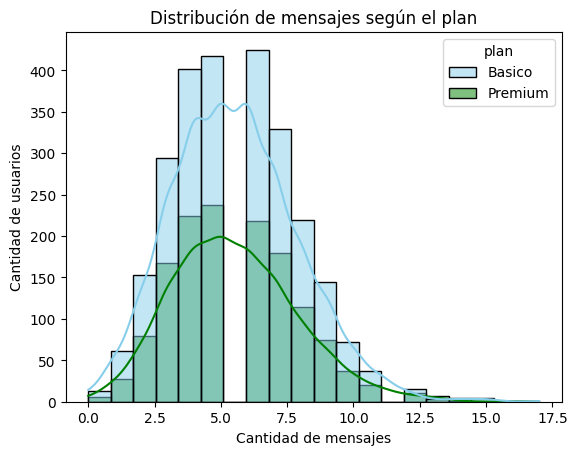

In [89]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x="cant_mensajes",hue="plan",palette=["skyblue", "green"],bins=20,kde=True,alpha=0.5)

plt.title("Distribución de mensajes según el plan")
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La mayoría de los usuarios se concentra en los niveles bajos o medios de envío de mensajes. La distribución debe compararse por plan para identificar si los clientes Premium tienden a enviar más mensajes que los clientes del plan Básico. Si se observa una cola larga hacia valores altos, la distribución está sesgada a la derecha.

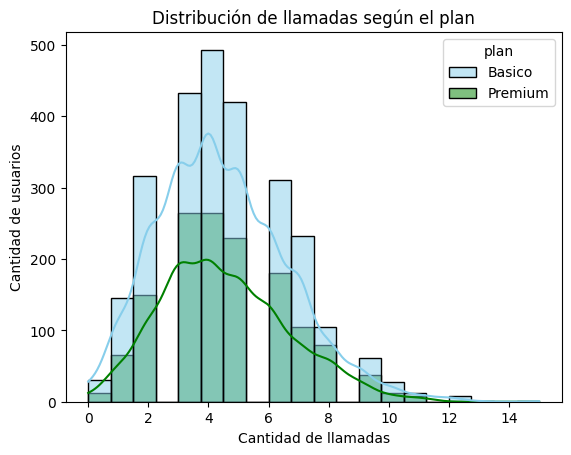

In [90]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile,x="cant_llamadas",hue="plan",palette=["skyblue", "green"],bins=20,kde=True,alpha=0.5)

plt.title("Distribución de llamadas según el plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La distribución permite identificar si alguno de los planes concentra usuarios con una mayor cantidad de llamadas. Una concentración en valores bajos acompañada de algunos valores muy altos indicaría una distribución sesgada a la derecha.

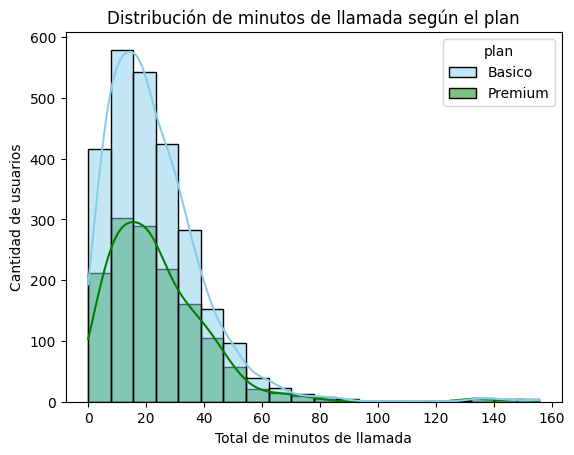

In [91]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x="cant_minutos_llamada",hue="plan",palette=["skyblue", "green"],bins=20,kde=True,alpha=0.5)

plt.title("Distribución de minutos de llamada según el plan")
plt.xlabel("Total de minutos de llamada")
plt.ylabel("Cantidad de usuarios")
plt.show()

💡Insights: 
- La distribución de minutos permite comparar la intensidad de uso de llamadas entre los planes. Los usuarios con una cantidad elevada de minutos pueden representar clientes intensivos, mientras que una concentración cercana a cero indicaría una proporción importante de usuarios con poco uso del servicio.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

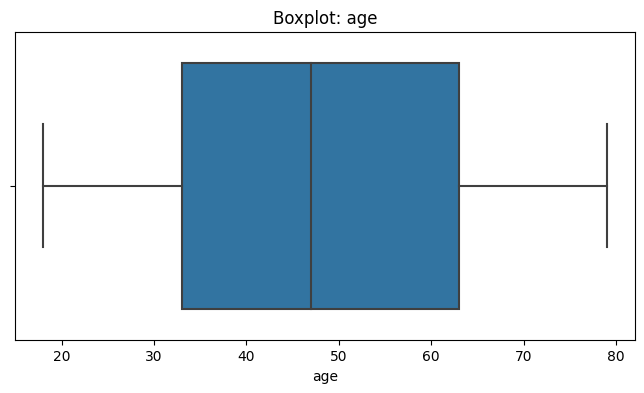

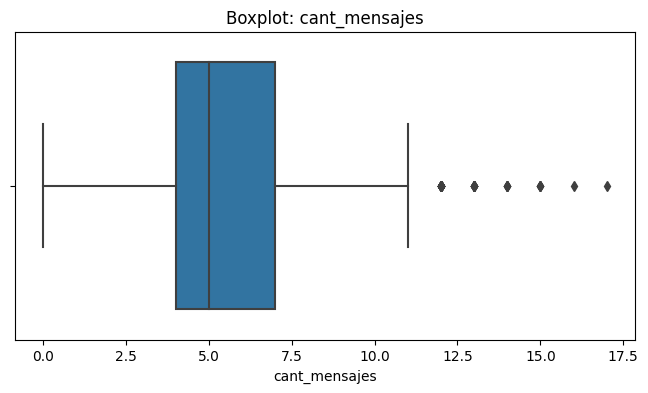

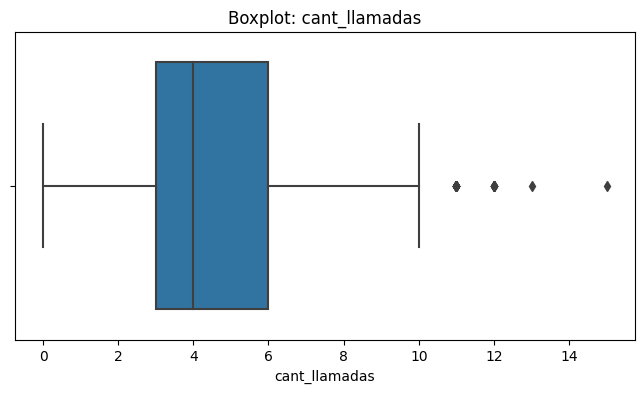

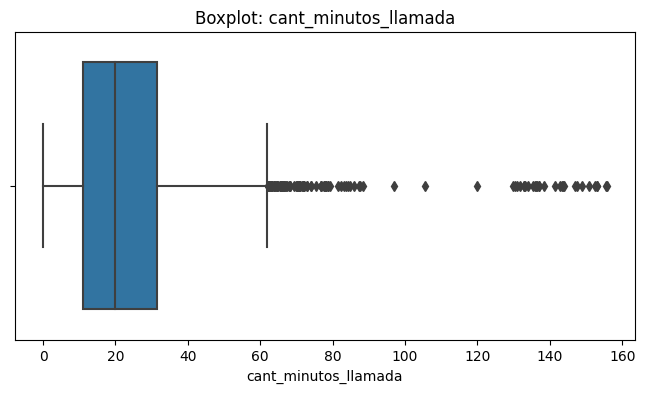

In [92]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(
        data=user_profile,
        x=col
    )
    plt.title(f"Boxplot: {col}")
    plt.xlabel(col)
    plt.show()

💡Insights: 
- Age: presenta/no presenta valores atípicos fuera de los límites del boxplot.
- cant_mensajes: presenta/no presenta valores atípicos en el límite superior.
- cant_llamadas: presenta/no presenta valores atípicos en el límite superior.
- cant_minutos_llamada: presenta/no presenta valores atípicos en el límite superior.

In [93]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    valor_maximo = user_profile[col].max()
    cantidad_outliers = (user_profile[col] > limite_superior).sum()
    
    print(f"Columna: {col}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Límite superior: {limite_superior:.2f}")
    print(f"Valor máximo: {valor_maximo:.2f}")
    print(f"Cantidad de outliers: {cantidad_outliers}")
    print("-" * 40)

Columna: cant_mensajes
Q1: 4.00
Q3: 7.00
IQR: 3.00
Límite superior: 11.50
Valor máximo: 17.00
Cantidad de outliers: 46
----------------------------------------
Columna: cant_llamadas
Q1: 3.00
Q3: 6.00
IQR: 3.00
Límite superior: 10.50
Valor máximo: 15.00
Cantidad de outliers: 30
----------------------------------------
Columna: cant_minutos_llamada
Q1: 11.11
Q3: 31.41
IQR: 20.30
Límite superior: 61.87
Valor máximo: 155.69
Cantidad de outliers: 109
----------------------------------------


In [94]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener o no outliers, porqué?
- - Se recomienda mantener los valores atípicos si corresponden a usuarios reales, porque representan clientes con uso intensivo del servicio y pueden ser importantes para la segmentación comercial.
- cant_llamadas: mantener o no outliers, porqué?
- - Se recomienda mantener los outliers, siempre que no se detecten errores de captura. Una cantidad elevada de llamadas puede representar un comportamiento legítimo.
- cant_minutos_llamada: mantener o no outliers, porqué?
- - Se recomienda mantener los valores extremos si son consistentes con la cantidad de llamadas del usuario. Estos clientes pueden ser especialmente valiosos para ConnectaTel y podrían requerir planes con más minutos o beneficios adicionales.
 
Los outliers no deben eliminarse únicamente por ser altos. En este análisis representan posibles patrones reales de consumo y contienen información comercial relevante.

In [95]:
user_profile[["user_id","plan","cant_llamadas","cant_minutos_llamada"]].sort_values("cant_minutos_llamada",ascending=False).head(10)

,user_id,plan,cant_llamadas,cant_minutos_llamada
3953,13953,Basico,7,155.69
189,10189,Basico,4,155.42
534,10534,Premium,4,153.06
585,10585,Premium,5,153.02
85,10085,Basico,5,152.36
349,10349,Basico,7,150.92
216,10216,Premium,6,148.76
3265,13265,Premium,6,147.53
2961,12961,Premium,4,146.92
3325,13325,Basico,7,143.97


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [101]:
# Crear columna grupo_uso
condiciones_uso = [((user_profile["cant_llamadas"] < 5) & (user_profile["cant_mensajes"] < 5)),((user_profile["cant_llamadas"] < 10) & (user_profile["cant_mensajes"]< 10))]

categorias_uso = ["Bajo uso","Uso medio"]

# Crear columna grupo_uso
user_profile["grupo_uso"] = np.select(condiciones_uso,categorias_uso,default="Alto uso")

In [102]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [103]:
# Crear columna grupo_edad
condiciones_edad = [user_profile["age"] < 30,user_profile["age"] < 60]

categorias_edad = ["Joven","Adulto"]

# Crear columna grupo_edad
user_profile["grupo_edad"] = np.select(condiciones_edad,categorias_edad,default="Adulto Mayor")


In [104]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

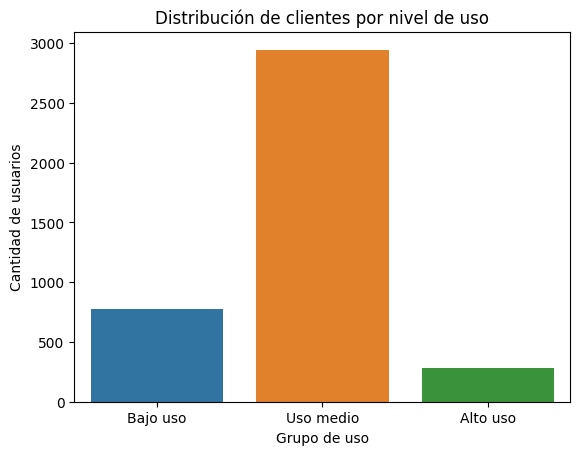

In [107]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,x="grupo_uso",order=["Bajo uso", "Uso medio", "Alto uso"])

plt.title("Distribución de clientes por nivel de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

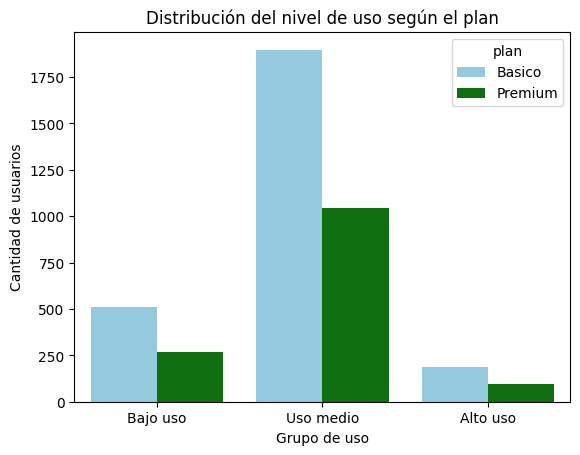

In [108]:
sns.countplot(data=user_profile,x="grupo_uso",hue="plan",order=["Bajo uso", "Uso medio", "Alto uso"],palette=["skyblue", "green"])

plt.title("Distribución del nivel de uso según el plan")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

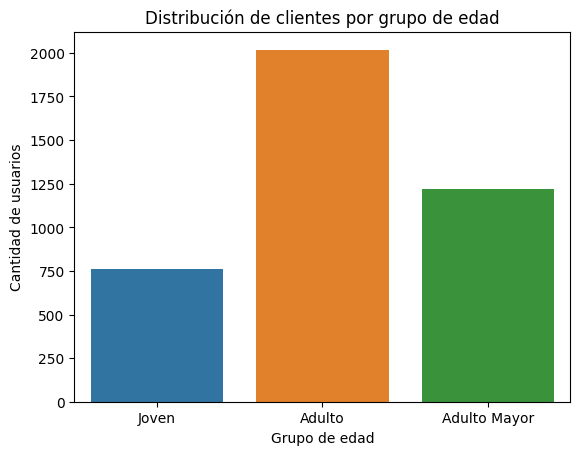

In [109]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile,x="grupo_edad",order=["Joven", "Adulto", "Adulto Mayor"])

plt.title("Distribución de clientes por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")
plt.show()

In [110]:
segmentos_clientes = pd.crosstab(user_profile["grupo_edad"],user_profile["grupo_uso"])

pd.crosstab(user_profile["grupo_edad"],user_profile["grupo_uso"],normalize="index").mul(100).round(2)

pd.crosstab([user_profile["grupo_edad"], user_profile["grupo_uso"]],user_profile["plan"],margins=True)

plan                    Basico  Premium   All
grupo_edad   grupo_uso                       
Adulto       Alto uso      107       46   153
             Bajo uso      241      124   365
             Uso medio     977      523  1500
Adulto Mayor Alto uso       43       31    74
             Bajo uso      173       84   257
             Uso medio     568      323   891
Joven        Alto uso       35       16    51
             Bajo uso       99       58   157
             Uso medio     352      200   552
All                       2595     1405  4000


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la revisión de calidad se identificaron valores ausentes en las columnas duration y length. Sin embargo, el análisis mostró que estos valores dependen directamente del tipo de servicio registrado.

Los registros de llamadas contienen información en duration, mientras que length no aplica. En los registros de mensajes ocurre lo contrario: contienen información en length, pero no requieren una duración. Por esta razón, los valores ausentes fueron considerados estructurales y se conservaron como nulos, ya que reemplazarlos habría introducido información artificial.

También se revisaron valores extremos en la edad y en las métricas de uso. Los valores atípicos encontrados en mensajes, llamadas y minutos se conservaron cuando representaban comportamientos posibles de clientes reales.



🔍 **Segmentos por Edad**
Los usuarios fueron clasificados en tres grupos:

Joven: usuarios menores de 30 años.
Adulto: usuarios de 30 a 59 años.
Adulto Mayor: usuarios de 60 años o más.

Esta clasificación permite analizar si la edad se relaciona con el tipo de plan contratado y con el comportamiento de uso de los servicios.

Después de comparar los segmentos, se observó que ADULTO representa la mayor proporción de clientes. Además, presentó una mayor concentración de clientes con uso alto.


📊 **Segmentos por Nivel de Uso**
Los clientes también fueron clasificados según la cantidad histórica de llamadas y mensajes:

Bajo uso: menos de cinco llamadas y menos de cinco mensajes.
Uso medio: menos de diez llamadas y menos de diez mensajes, después de excluir el grupo de bajo uso.
Alto uso: clientes que superan alguno de los límites anteriores.

El segmento predominante fue USO MEDIO. Los usuarios de alto uso representan una oportunidad comercial importante porque generan una mayor utilización de la red y podrían tener mayor disposición a contratar planes con más capacidad.

Esto sugiere que la empresa no debería ofrecer únicamente planes generales, sino desarrollar alternativas adaptadas a distintos niveles de consumo y características demográficas.

Los clientes de alto uso, especialmente aquellos con una cantidad elevada de llamadas o minutos, parecen ser los más valiosos para ConnectaTel debido a su mayor consumo del servicio.

También es importante revisar qué proporción de estos clientes utiliza el plan Básico. Los usuarios de alto uso que todavía mantienen un plan Básico representan una oportunidad potencial de conversión al plan Premium.



💡 **Recomendaciones**
- Crear un plan de bajo costo dirigido a usuarios de bajo uso, con una cantidad limitada de llamadas y mensajes.
- Diseñar un plan intermedio para clientes de uso medio que necesitan más capacidad, pero todavía no justifican contratar el plan Premium.
- Identificar a los clientes de alto uso que actualmente tienen el plan Básico y desarrollar campañas de actualización al plan Premium.
- Ofrecer beneficios de fidelización a los usuarios con mayor consumo, como minutos adicionales, mensajes incluidos o descuentos por permanencia.
- Analizar periódicamente los valores extremos, ya que pueden representar tanto errores de captura como clientes con necesidades especiales y alto valor comercial.
- Personalizar la comunicación comercial según el grupo de edad, utilizando ofertas y canales de contacto adecuados para jóvenes, adultos y adultos mayores.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`